In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Data Importing

In [23]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df = df.drop('customerID', axis=1)

In [28]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

## Data Cleaning

In [29]:
data = df.copy()



missing_data = data[data['TotalCharges'].isna()]
print("Missing TotalCharges: ", missing_data.shape[0], "rows")

Missing TotalCharges:  11 rows


In [30]:

data["TotalCharges"] = data["TotalCharges"].fillna(0)
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})


## Overview Data Exploratory

In [31]:
churn_rate = data['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")


Overall churn rate: 26.54%


Text(0.5, 1.0, 'Churn Distribution by Gender')

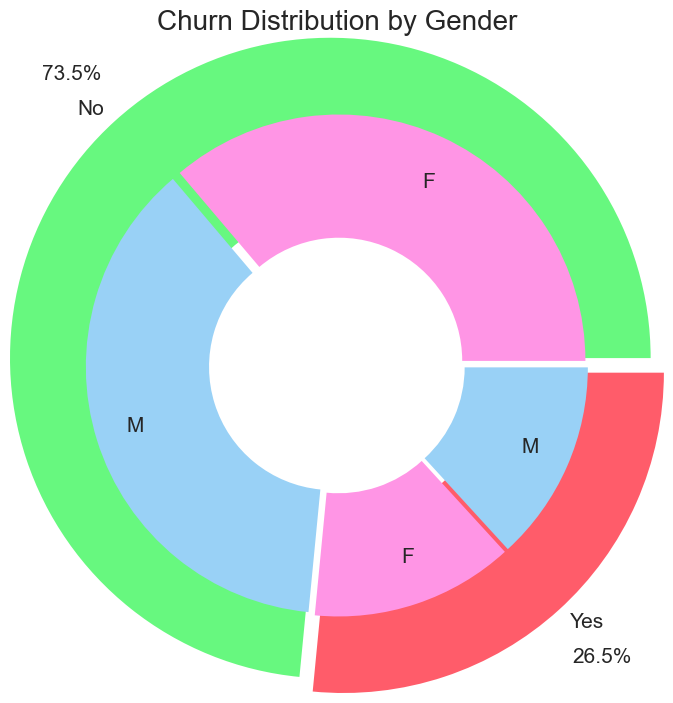

In [32]:


churn_counts = df['Churn'].value_counts()
group_counts = df.groupby(["Churn", "gender"]).size()


inner_labels = churn_counts.index
inner_sizes = churn_counts.values

outer_labels = [f"{gender[1][0]}" for gender in group_counts.index]
outer_sizes = group_counts.values

fig, ax = plt.subplots(figsize=(8,8))

ax.pie(
    inner_sizes,
    radius=1.3,
    labels=inner_labels,
    colors=["#67F87F", "#FF5C6A"],
    explode=[0.04,0.04],
    autopct='%1.1f%%',
    pctdistance=1.2,
    labeldistance=1.05,
    wedgeprops=dict(width=0.7, edgecolor='none', linewidth=1),
    textprops={'fontsize': 15}

)

ax.pie(
    outer_sizes,
    radius=1.0,
    labels=outer_labels,
    colors=["#ff95e5", "#99d1f6","#ff95e5", "#99d1f6"],
    explode=[0.02,0.02,0.02,0.02],
    wedgeprops=dict(width=0.5, edgecolor='none', linewidth=0),
    labeldistance=0.8,
    textprops={'fontsize': 15}
    
)


ax.set_title("Churn Distribution by Gender", pad=20, fontsize=20)


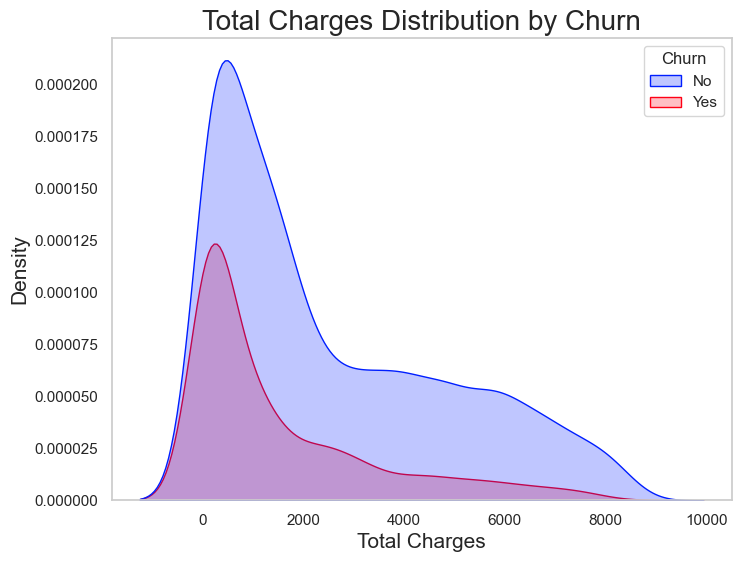

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, palette=["#001EFF", "#FF0015"])
ax.grid(False)
ax.set_title("Total Charges Distribution by Churn", fontsize=20)
ax.set_xlabel("Total Charges", fontsize=15)
ax.set_ylabel("Density", fontsize=15)
plt.show()


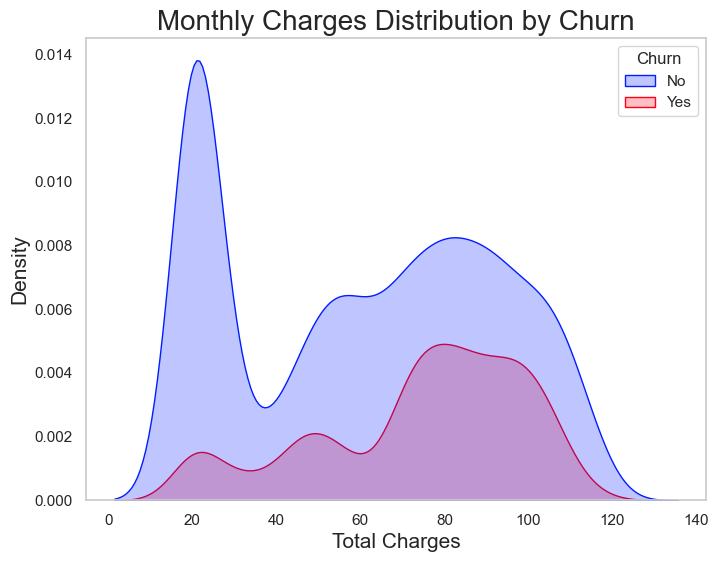

In [34]:
fig, ax = plt.subplots(figsize=(8,6))
ax = sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, palette=["#001EFF", "#FF0015"])
ax.grid(False)
ax.set_title("Monthly Charges Distribution by Churn", fontsize=20)
ax.set_xlabel("Total Charges", fontsize=15)
ax.set_ylabel("Density", fontsize=15)
plt.show()


C:\Users\kim_c\AppData\Local\Temp\ipykernel_12256\2519595126.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spec = spec.replace({'Yes': 1, 'No': 0})


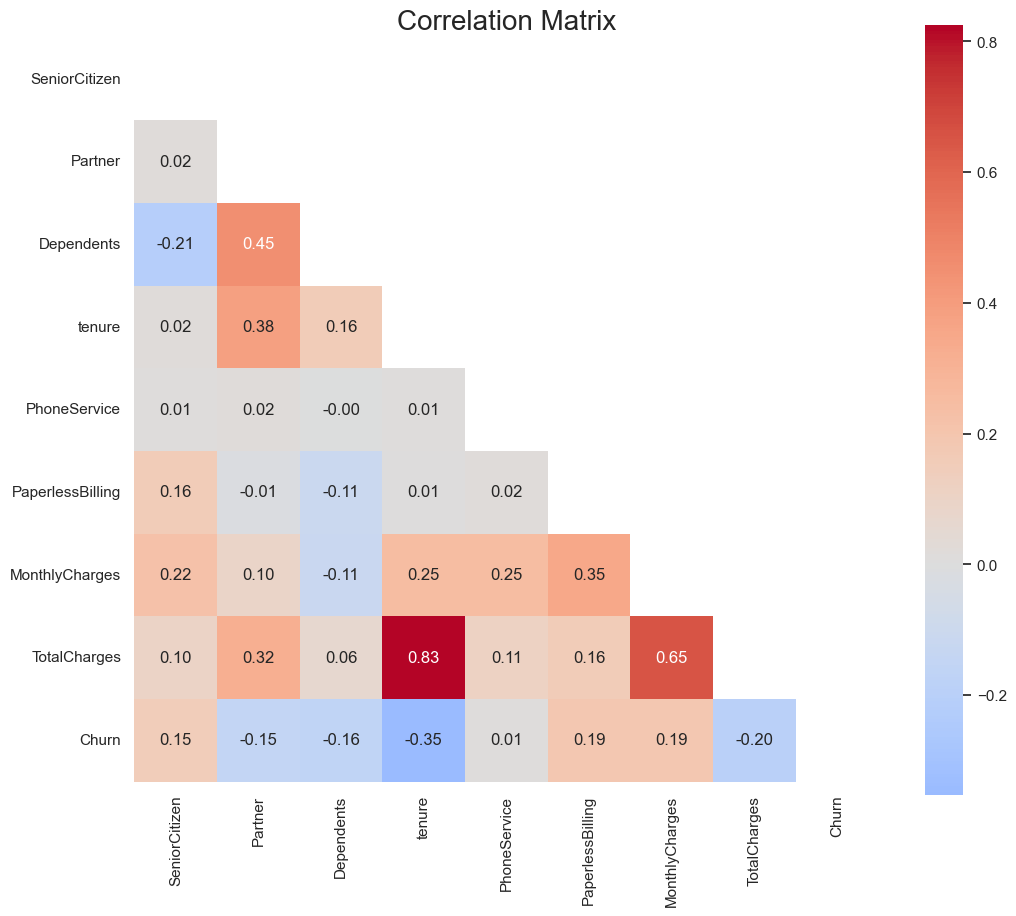

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

spec = df[['SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling',
        'MonthlyCharges', 'TotalCharges', 'Churn']]

spec = spec.replace({'Yes': 1, 'No': 0})
corr = spec.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    mask=mask
)
plt.grid(False)

plt.title("Correlation Matrix", fontsize=20)
plt.show()

## Feature Engineering

In [36]:
feat = data.copy()
feat['avg_charge'] = feat["TotalCharges"] / (feat['tenure'] + 1)

feat['is_new_customer'] = (feat['tenure'] < 15).astype(int)

feat['has_family'] = ((feat['Partner'] == 'Yes') | (feat['Dependents'] == 'Yes')).astype(int)

addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
feat['addon_count'] = feat[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

feat.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_charge,is_new_customer,has_family,addon_count
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,14.925000,1,1,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,53.985714,0,0,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,36.050000,1,0,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.016304,0,0,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,50.550000,1,0,0


In [37]:
baseline_data = data.copy()
improved_data = feat.copy()

baseline_data.shape, improved_data.shape

((7043, 20), (7043, 24))

## Preprocessing

In [38]:
#Helper functions

def split_xy(df, target_col="Churn"):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
        )

def preprocessor(X):
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    num_cols = X.select_dtypes(exclude='object').columns.tolist()

    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    return preprocessor, num_cols, cat_cols

def evaluate(model, X_train, X_test, y_train, y_test, threshold=0.5, model_name="Model"):
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    auc = roc_auc_score(y_test, proba)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"=== {model_name} ===")
    print(f"AUC      : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_test, pred))

    return {
        "model": model_name,
        "proba": proba,
        "pred": pred,
        "auc": auc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def cross_validate_auc(model, X, y, model_name='Model'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring=["roc_auc", "precision", "recall", "f1"],
        n_jobs=-1
    )

    results = pd.DataFrame({
        "roc_auc": scores["test_roc_auc"],
        "precision": scores["test_precision"],
        "recall": scores["test_recall"],
        "f1": scores["test_f1"]
    })

    print(f"=== CV Results: {model_name} ===")
    print(results.mean().round(4))
    print()
    return results

In [39]:
X_train_base, X_test_base, y_train_base, y_test_base = split_xy(baseline_data)
X_train_imp, X_test_imp, y_train_imp, y_test_imp = split_xy(improved_data)

## Training

1. Baseline Logistic Regression

In [40]:
preprocessor_base, num_cols_base, cat_cols_base = preprocessor(X_train_base)

logreg_base = Pipeline([
    ("prep", preprocessor_base),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_result = evaluate(
    logreg_base,
    X_train_base, X_test_base,
    y_train_base, y_test_base,
    threshold=0.5,
    model_name="Baseline Logistic Regression"
)

=== Baseline Logistic Regression ===
AUC      : 0.8421
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [41]:
cv_X_base = baseline_data.drop(columns=["Churn"])
cv_y_base = baseline_data["Churn"]

baseline_cv = cross_validate_auc(
    logreg_base, cv_X_base, cv_y_base,
    model_name="Baseline Logistic Regression"
)

=== CV Results: Baseline Logistic Regression ===
roc_auc      0.8451
precision    0.6584
recall       0.5527
f1           0.6008
dtype: float64



2. Balanced Logistic Regression

In [42]:
logreg_balanced = Pipeline([
    ("prep", preprocessor_base),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'))
])

balanced_result = evaluate(
    logreg_balanced,
    X_train_base, X_test_base,
    y_train_base, y_test_base,
    threshold=0.5,
    model_name="Baseline Logistic Regression"
)

=== Baseline Logistic Regression ===
AUC      : 0.8416
Precision: 0.5043
Recall   : 0.7834
F1-score : 0.6136

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [43]:
balanced_cv = cross_validate_auc(
    logreg_balanced, cv_X_base, cv_y_base,
    model_name="Balanced Logistic Regression"
)

=== CV Results: Balanced Logistic Regression ===
roc_auc      0.8450
precision    0.5132
recall       0.8020
f1           0.6258
dtype: float64



3. Improved Logistic Regression

In [44]:
preprocessor_imp, num_cols_imp, cat_cols_imp = preprocessor(X_train_imp)

logreg_imp = Pipeline([
    ("prep", preprocessor_imp),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])

imp_result = evaluate(
    logreg_imp,
    X_train_imp, X_test_imp,
    y_train_imp, y_test_imp,
    threshold=0.5,
    model_name="Improved Logistic Regression"
)

=== Improved Logistic Regression ===
AUC      : 0.8466
Precision: 0.6757
Recall   : 0.5348
F1-score : 0.5970

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [45]:
cv_X_imp = improved_data.drop(columns=["Churn"])
cv_y_imp = improved_data["Churn"]

improved_cv = cross_validate_auc(
    logreg_imp, cv_X_imp, cv_y_imp,
    model_name="Improved Logistic Regression"
)

=== CV Results: Improved Logistic Regression ===
roc_auc      0.8476
precision    0.6738
recall       0.5291
f1           0.5927
dtype: float64



4. Random Forest Classification

In [46]:
rf_base = Pipeline([
    ("prep", preprocessor_imp),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_result = evaluate(
    rf_base,
    X_train_imp, X_test_imp,
    y_train_imp, y_test_imp,
    threshold=0.5,
    model_name="Random Forest"
)

=== Random Forest ===
AUC      : 0.8213
Precision: 0.6027
Recall   : 0.4706
F1-score : 0.5285

              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [47]:
rf_cv = cross_validate_auc(
    rf_base, cv_X_imp, cv_y_imp,
    model_name="Random Forest"
)

=== CV Results: Random Forest ===
roc_auc      0.8242
precision    0.6422
recall       0.4858
f1           0.5529
dtype: float64



## Summary

In [48]:
comparison = pd.DataFrame([
    {
        "Model": "Baseline Logistic",
        "AUC": baseline_result["auc"],
        "Precision": baseline_result["precision"],
        "Recall": baseline_result["recall"],
        "F1": baseline_result["f1"]
    },
    {
        "Model": "Balanced Logistic",
        "AUC": balanced_result["auc"],
        "Precision": balanced_result["precision"],
        "Recall": balanced_result["recall"],
        "F1": balanced_result["f1"]
    },
    {
        "Model": "Improved Logistic",
        "AUC": imp_result["auc"],
        "Precision": imp_result["precision"],
        "Recall": imp_result["recall"],
        "F1": imp_result["f1"]
    },
    {
        "Model": "Random Forest",
        "AUC": rf_result["auc"],
        "Precision": rf_result["precision"],
        "Recall": rf_result["recall"],
        "F1": rf_result["f1"]
    }
])

comparison.sort_values("AUC", ascending=False)

,Model,AUC,Precision,Recall,F1
2,Improved Logistic,0.846589,0.675676,0.534759,0.597015
0,Baseline Logistic,0.842135,0.657233,0.558824,0.604046
1,Balanced Logistic,0.841639,0.504303,0.783422,0.613613
3,Random Forest,0.821256,0.602740,0.470588,0.528529
